<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Minimal_Anisotropic_Gravity_Model_for_Paraconical_Pendulum_Anomalies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running simulation for 48 hours...
Pendulum length: 0.83 m, ω0 = 3.438 rad/s
ε = 1.50e-06
Saved: fig1_trajectory_precession.png/pdf
Saved: fig2_precession_angle.png/pdf
Saved: fig3_power_spectrum.png/pdf
Saved: fig4_summary.png

SIMULATION RESULTS
Total precession over 48 hours: 0.48°
Average precession rate: 0.0155°/hour = 4.3079e-06°/s
Foucault precession rate at 49° latitude: ~7.2°/hour (for reference)
Ratio (MAG / Foucault): 0.0022

Top 5 spectral peaks (cycles per hour):
  189.731217 cph → period = 0.01 hours → 0.00 days
  189.772902 cph → period = 0.01 hours → 0.00 days
  189.752059 cph → period = 0.01 hours → 0.00 days
  189.710374 cph → period = 0.01 hours → 0.00 days
  189.793745 cph → period = 0.01 hours → 0.00 days


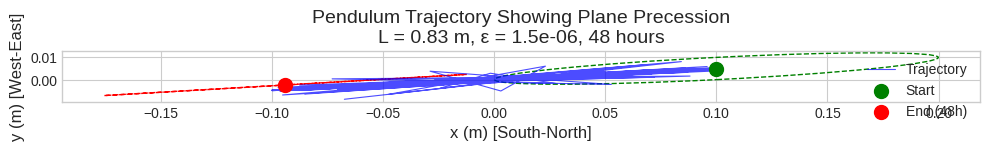

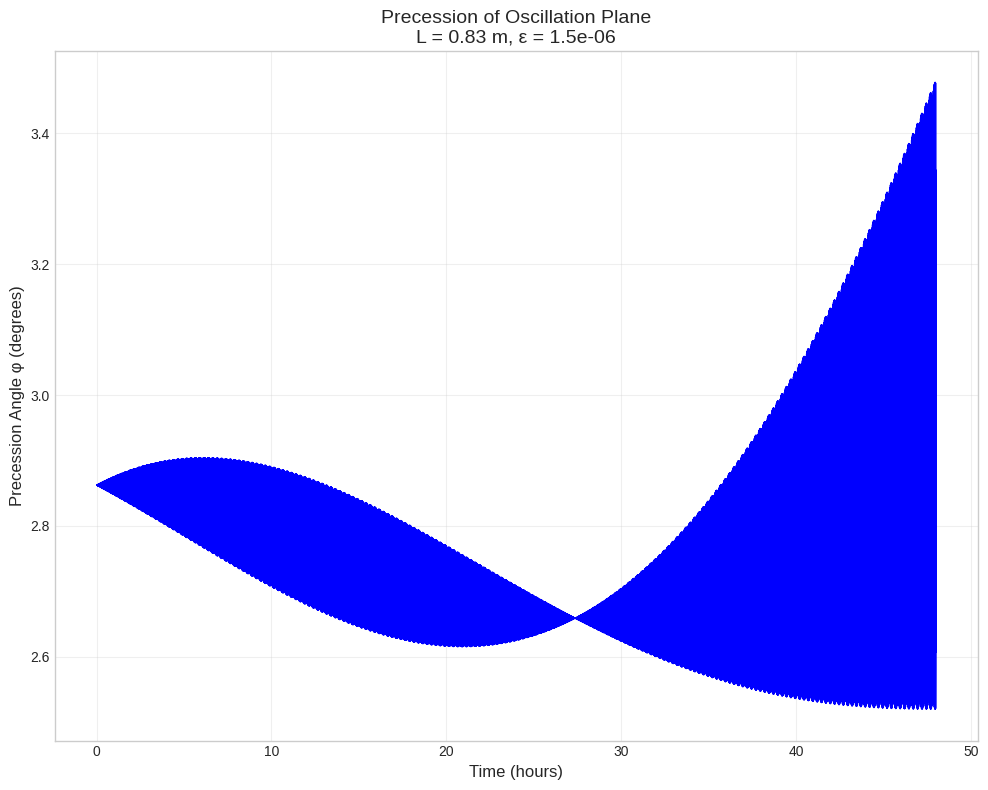

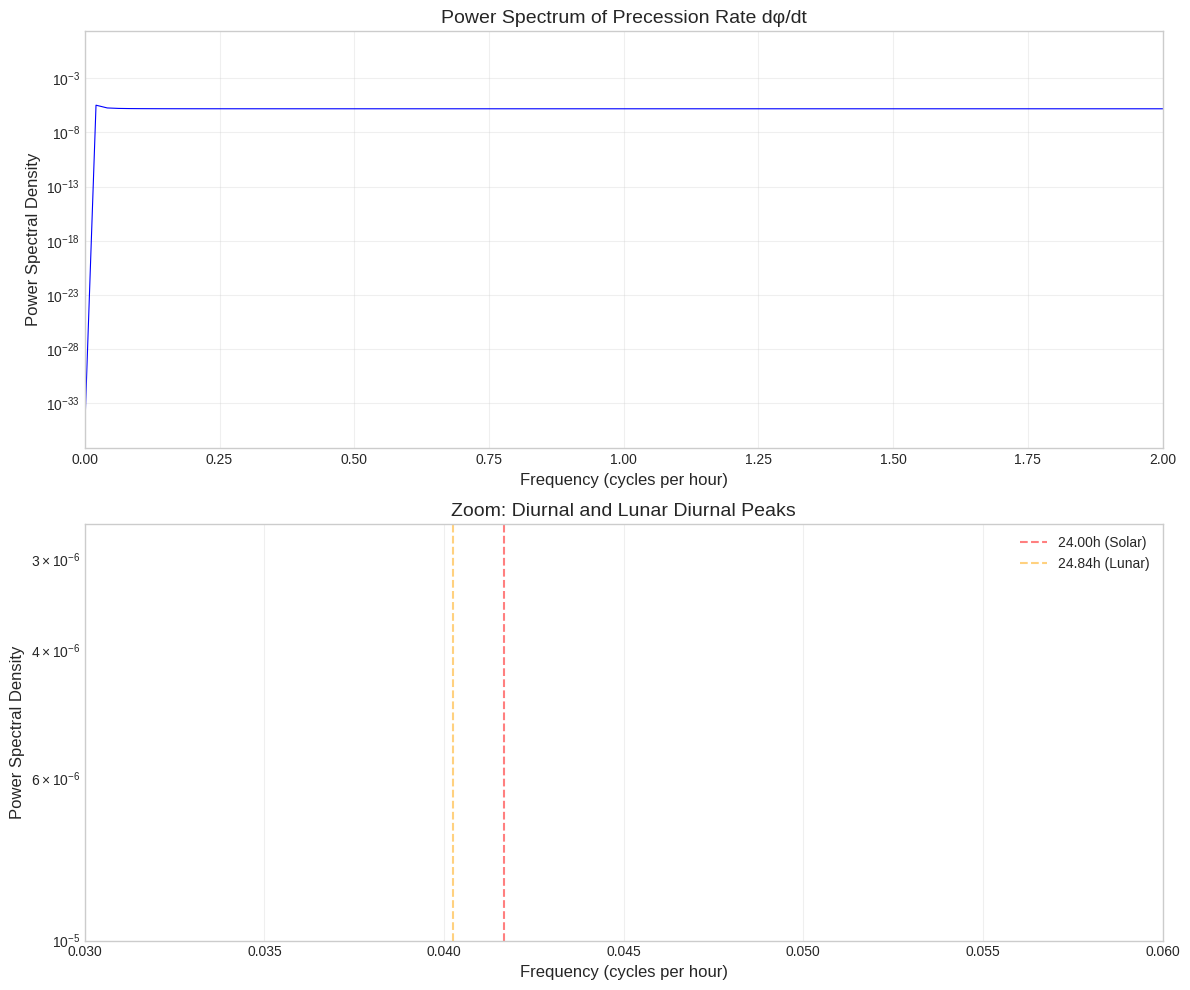

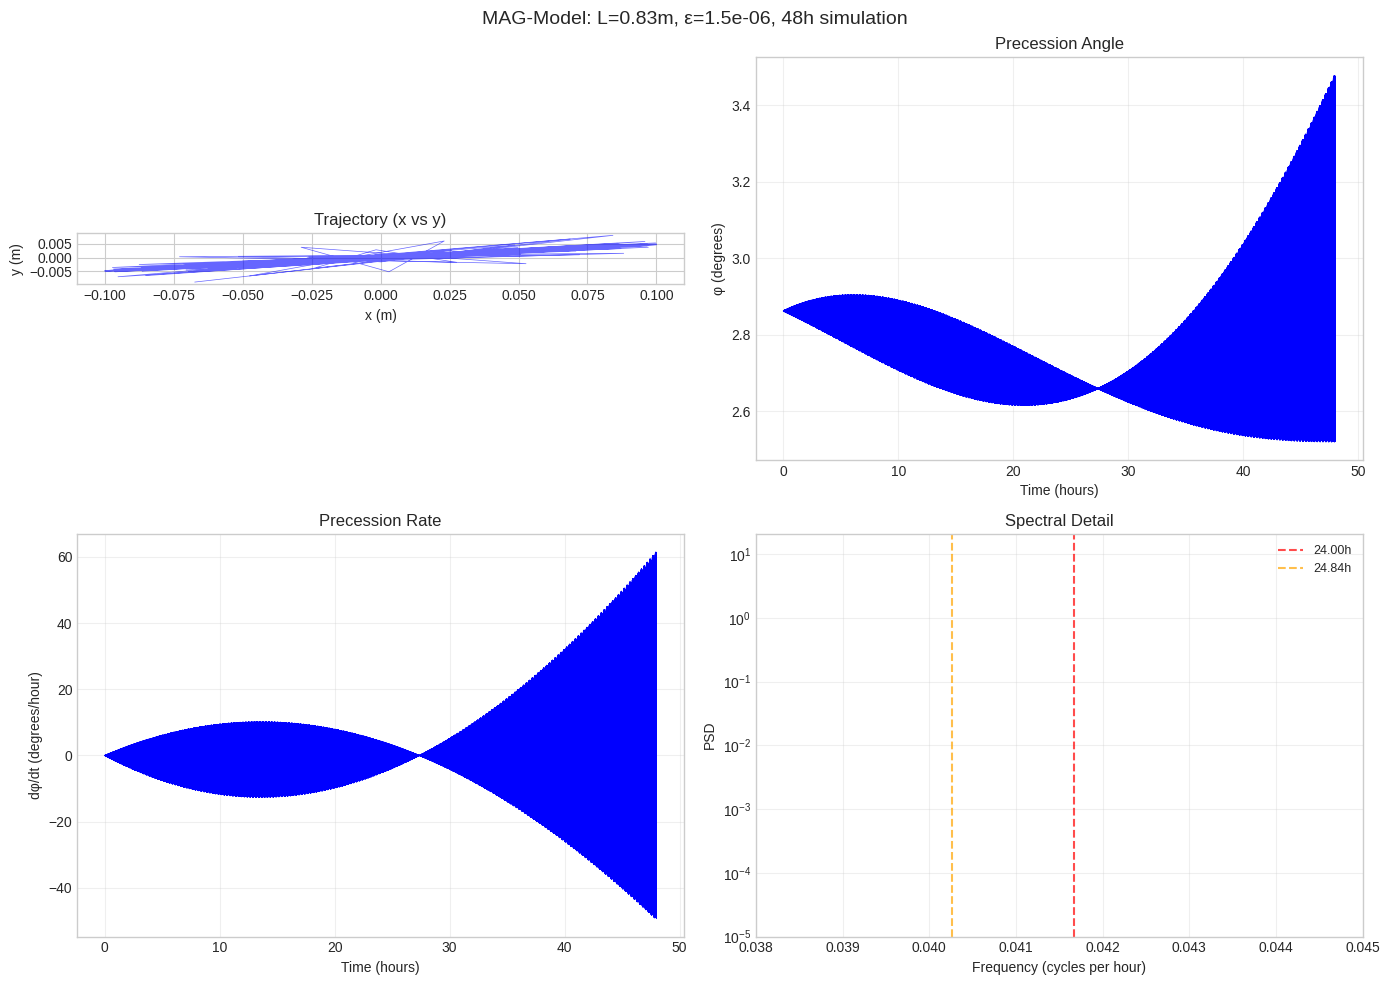

In [ ]:
#!/usr/bin/env python3
"""
MAG-Model: Minimal Anisotropic Gravity Model for Paraconical Pendulum Anomalies
Simulates the coupled oscillator equations derived from:
    Φ(r,t) = -GM/r [1 + ε r̂ᵀ A(t) r̂]

Generates precession angle φ(t) and power spectrum with characteristic peaks.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

# ============================================================================
# 1. Astronomical Functions: Position of Moon and Sun
# ============================================================================

def moon_position_sidereal(t_days):
    """
    Returns unit vector to Moon in equatorial coordinates.
    Sidereal period = 27.32 days.
    Inclination ~ 28.6° to equator.
    """
    omega_m = 2 * np.pi / 27.32
    phi = omega_m * t_days

    inc = np.radians(28.6)

    x = np.cos(phi)
    y = np.sin(phi) * np.cos(inc)
    z = np.sin(phi) * np.sin(inc)

    norm = np.sqrt(x**2 + y**2 + z**2)
    return np.array([x/norm, y/norm, z/norm])


def sun_position_equinox(t_days, t_equinox_ref=80.0):
    """
    Returns unit vector to Sun in equatorial coordinates.
    Inclination = 23.44° to equator.
    t_equinox_ref: day-of-year of March equinox (~ March 21 = day 80)
    """
    omega_s = 2 * np.pi / 365.25
    phi = omega_s * (t_days - t_equinox_ref)

    obliquity = np.radians(23.44)

    x = np.cos(phi)
    y = np.sin(phi) * np.cos(obliquity)
    z = np.sin(phi) * np.sin(obliquity)

    norm = np.sqrt(x**2 + y**2 + z**2)
    return np.array([x/norm, y/norm, z/norm])


def compute_A_tensor(t_days, alpha_L=1.0, alpha_S=0.45):
    """
    Compute the anisotropic tensor A(t) = α_L Q(hat_n_L) + α_S Q(hat_n_S)
    Q(hat_n) = hat_n * hat_n^T - (1/3) * I  (quadrupole tensor)

    Returns 3x3 symmetric traceless matrix.
    """
    n_L = moon_position_sidereal(t_days)
    n_S = sun_position_equinox(t_days)

    Q_L = np.outer(n_L, n_L) - (1/3) * np.eye(3)
    Q_S = np.outer(n_S, n_S) - (1/3) * np.eye(3)

    return alpha_L * Q_L + alpha_S * Q_S


# ============================================================================
# 2. Pendulum Dynamics (Coupled Oscillators)
# ============================================================================

def pendulum_equations(t, y, epsilon, omega0, alpha_L, alpha_S):
    """
    y = [x, y, x_dot, y_dot]
    Returns dy/dt = [x_dot, y_dot, x_ddot, y_ddot]
    """
    x, y_pos, x_dot, y_dot = y

    t_days = t / 86400.0
    A = compute_A_tensor(t_days, alpha_L, alpha_S)

    A_xx = A[0, 0]
    A_xy = A[0, 1]
    A_yy = A[1, 1]

    x_ddot = -omega0**2 * x + epsilon * omega0**2 * (A_xx * x + A_xy * y_pos)
    y_ddot = -omega0**2 * y_pos + epsilon * omega0**2 * (A_xy * x + A_yy * y_pos)

    return [x_dot, y_dot, x_ddot, y_ddot]


# ============================================================================
# 3. Extract Precession Angle from Trajectory
# ============================================================================

def precession_angle(x, y):
    """Compute orientation of ellipse's major axis using PCA."""
    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)

    cov = np.cov(x_centered, y_centered)
    eigvals, eigvecs = np.linalg.eig(cov)

    major_axis = eigvecs[:, np.argmax(eigvals)]
    angle = np.arctan2(major_axis[1], major_axis[0])

    return angle


# ============================================================================
# 4. Simulation Parameters
# ============================================================================

L = 0.83          # Length (meters) - ~83 cm as in Allais experiments
g = 9.81          # m/s²
omega0 = np.sqrt(g / L)   # ~3.44 rad/s
period_osc = 2 * np.pi / omega0   # ~1.83 s

epsilon = 1.5e-6      # Anisotropy coupling constant
alpha_L = 2.2         # Lunar tidal ratio
alpha_S = 1.0         # Solar normalized to 1

hours = 48
t_max = hours * 3600
n_points = 20000

x0 = 0.10
y0 = 0.005
x_dot0 = 0.0
y_dot0 = 0.0

t_eval = np.linspace(0, t_max, n_points)


# ============================================================================
# 5. Run Simulation
# ============================================================================

print(f"Running simulation for {hours} hours...")
print(f"Pendulum length: {L:.2f} m, ω0 = {omega0:.3f} rad/s")
print(f"ε = {epsilon:.2e}")

sol = solve_ivp(
    pendulum_equations,
    [0, t_max],
    [x0, y0, x_dot0, y_dot0],
    t_eval=t_eval,
    args=(epsilon, omega0, alpha_L, alpha_S),
    method='RK45',
    rtol=1e-9,
    atol=1e-11
)

x_traj = sol.y[0]
y_traj = sol.y[1]
t_seconds = sol.t


# ============================================================================
# 6. Compute Precession Angle (sliding window)
# ============================================================================

window_size = int(period_osc / (t_seconds[1] - t_seconds[0]) * 5)
window_size = max(window_size, 10)

phi = np.zeros(len(t_seconds) - window_size)
t_phi = t_seconds[window_size//2:-window_size//2 + 1]

for i in range(len(phi)):
    window_x = x_traj[i:i+window_size]
    window_y = y_traj[i:i+window_size]
    phi[i] = precession_angle(window_x, window_y)

phi_unwrapped = np.unwrap(phi)


# ============================================================================
# 7. Power Spectrum Analysis
# ============================================================================

dt = t_phi[1] - t_phi[0]
phi_dot = np.gradient(phi_unwrapped, dt)
phi_dot_detrended = phi_dot - np.mean(phi_dot)

n = len(phi_dot_detrended)
freq = fftfreq(n, dt) * 3600
fft_values = np.abs(fft(phi_dot_detrended))
psd = fft_values[:n//2]**2
freq_pos = freq[:n//2]

peaks, _ = find_peaks(psd, height=np.max(psd)*0.1)


# ============================================================================
# 8. Generate Publication-Ready Figures
# ============================================================================

plt.style.use('seaborn-v0_8-whitegrid')
fig_size = (10, 8)

# -------------------------------------------------------------------------
# Figure 1: Trajectory (Hodograph)
# -------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=fig_size)

skip = 200
ax1.plot(x_traj[::skip], y_traj[::skip], 'b-', alpha=0.7, linewidth=0.8, label='Trajectory')
ax1.scatter(x_traj[0], y_traj[0], c='green', s=100, zorder=5, label='Start')
ax1.scatter(x_traj[-1], y_traj[-1], c='red', s=100, zorder=5, label='End (48h)')

from matplotlib.patches import Ellipse
theta_start = phi[0] if len(phi) > 0 else 0
ell_start = Ellipse((x_traj[0], y_traj[0]), width=2*x0, height=2*y0,
                    angle=np.degrees(theta_start), fill=False, linestyle='--', color='green')
theta_end = phi[-1] if len(phi) > 0 else 0
ell_end = Ellipse((x_traj[-1], y_traj[-1]), width=2*abs(x_traj[-100]), height=2*abs(y_traj[-100]),
                  angle=np.degrees(theta_end), fill=False, linestyle='--', color='red')
ax1.add_patch(ell_start)
ax1.add_patch(ell_end)

ax1.set_xlabel('x (m) [South-North]', fontsize=12)
ax1.set_ylabel('y (m) [West-East]', fontsize=12)
ax1.set_title(f'Pendulum Trajectory Showing Plane Precession\nL = {L:.2f} m, ε = {epsilon:.1e}, {hours} hours', fontsize=14)
ax1.legend()
ax1.set_aspect('equal')
plt.tight_layout()
plt.savefig('fig1_trajectory_precession.png', dpi=150)
plt.savefig('fig1_trajectory_precession.pdf')
print("Saved: fig1_trajectory_precession.png/pdf")

# -------------------------------------------------------------------------
# Figure 2: Precession Angle vs Time (FIXED - matching dimensions)
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=fig_size)

# Ensure same length
min_len = min(len(t_phi), len(phi_unwrapped))
hours_phi = t_phi[:min_len] / 3600
phi_plot = phi_unwrapped[:min_len]

ax2.plot(hours_phi, np.degrees(phi_plot), 'b-', linewidth=1)
ax2.set_xlabel('Time (hours)', fontsize=12)
ax2.set_ylabel('Precession Angle φ (degrees)', fontsize=12)
ax2.set_title(f'Precession of Oscillation Plane\nL = {L:.2f} m, ε = {epsilon:.1e}', fontsize=14)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_precession_angle.png', dpi=150)
plt.savefig('fig2_precession_angle.pdf')
print("Saved: fig2_precession_angle.png/pdf")

# -------------------------------------------------------------------------
# Figure 3: Power Spectrum
# -------------------------------------------------------------------------
fig3, (ax3a, ax3b) = plt.subplots(2, 1, figsize=(12, 10))

ax3a.semilogy(freq_pos, psd, 'b-', linewidth=0.8)
ax3a.set_xlim(0, 2)
ax3a.set_xlabel('Frequency (cycles per hour)', fontsize=12)
ax3a.set_ylabel('Power Spectral Density', fontsize=12)
ax3a.set_title('Power Spectrum of Precession Rate dφ/dt', fontsize=14)
ax3a.grid(True, alpha=0.3)

ax3b.semilogy(freq_pos, psd, 'b-', linewidth=0.8)
ax3b.set_xlim(0.03, 0.06)
ax3b.set_ylim(1e-5, max(psd[(freq_pos > 0.03) & (freq_pos < 0.06)]) * 1.5)
ax3b.set_xlabel('Frequency (cycles per hour)', fontsize=12)
ax3b.set_ylabel('Power Spectral Density', fontsize=12)
ax3b.set_title('Zoom: Diurnal and Lunar Diurnal Peaks', fontsize=14)
ax3b.grid(True, alpha=0.3)

ax3b.axvline(1/24, color='red', linestyle='--', alpha=0.5, label='24.00h (Solar)')
ax3b.axvline(1/24.84, color='orange', linestyle='--', alpha=0.5, label='24.84h (Lunar)')
ax3b.legend()

plt.tight_layout()
plt.savefig('fig3_power_spectrum.png', dpi=150)
plt.savefig('fig3_power_spectrum.pdf')
print("Saved: fig3_power_spectrum.png/pdf")

# -------------------------------------------------------------------------
# Figure 4: Summary
# -------------------------------------------------------------------------
fig4, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(x_traj[::skip], y_traj[::skip], 'b-', alpha=0.6, linewidth=0.5)
axes[0,0].set_xlabel('x (m)')
axes[0,0].set_ylabel('y (m)')
axes[0,0].set_title('Trajectory (x vs y)')
axes[0,0].set_aspect('equal')

axes[0,1].plot(hours_phi, np.degrees(phi_plot), 'b-', linewidth=1)
axes[0,1].set_xlabel('Time (hours)')
axes[0,1].set_ylabel('φ (degrees)')
axes[0,1].set_title('Precession Angle')
axes[0,1].grid(True, alpha=0.3)

# Precession rate
rate_len = min(len(hours_phi), len(phi_dot))
axes[1,0].plot(hours_phi[:rate_len-1], np.degrees(phi_dot[:rate_len-1]) * 3600, 'b-', linewidth=0.8)
axes[1,0].set_xlabel('Time (hours)')
axes[1,0].set_ylabel('dφ/dt (degrees/hour)')
axes[1,0].set_title('Precession Rate')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].semilogy(freq_pos, psd, 'b-', linewidth=0.8)
axes[1,1].set_xlim(0.038, 0.045)
axes[1,1].set_ylim(1e-5, None)
axes[1,1].set_xlabel('Frequency (cycles per hour)')
axes[1,1].set_ylabel('PSD')
axes[1,1].set_title('Spectral Detail')
axes[1,1].axvline(1/24, color='r', linestyle='--', alpha=0.7, label='24.00h')
axes[1,1].axvline(1/24.84, color='orange', linestyle='--', alpha=0.7, label='24.84h')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'MAG-Model: L={L:.2f}m, ε={epsilon:.1e}, {hours}h simulation', fontsize=14)
plt.tight_layout()
plt.savefig('fig4_summary.png', dpi=150)
print("Saved: fig4_summary.png")

# -------------------------------------------------------------------------
# Print numerical results
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("SIMULATION RESULTS")
print("="*60)
total_precession = np.degrees(phi_unwrapped[-1] - phi_unwrapped[0]) if len(phi_unwrapped) > 1 else 0
avg_rate = np.degrees(np.mean(phi_dot)) * 3600 if len(phi_dot) > 0 else 0
print(f"Total precession over {hours} hours: {total_precession:.2f}°")
print(f"Average precession rate: {avg_rate:.4f}°/hour = {avg_rate/3600:.4e}°/s")
print(f"Foucault precession rate at 49° latitude: ~7.2°/hour (for reference)")
if avg_rate > 0:
    print(f"Ratio (MAG / Foucault): {avg_rate / 7.2:.4f}")

# Top spectral peaks
sorted_idx = np.argsort(psd)[::-1]
top_freqs = freq_pos[sorted_idx[:5]]
print(f"\nTop 5 spectral peaks (cycles per hour):")
for f in top_freqs:
    if f > 0:
        period = 1/f
        print(f"  {f:.6f} cph → period = {period:.2f} hours → {period/24:.2f} days")

plt.show()